In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fd_coefficients import fd_coefficients
from model import homogeneous_model
from source import ricker
from solver import acoustic_solver_Dirichlet,acoustic_solver_Damping
from boundary import damping_boundary

FD order = 8
FD coefficients = [ 1.6        -0.2         0.02539683 -0.00178571]


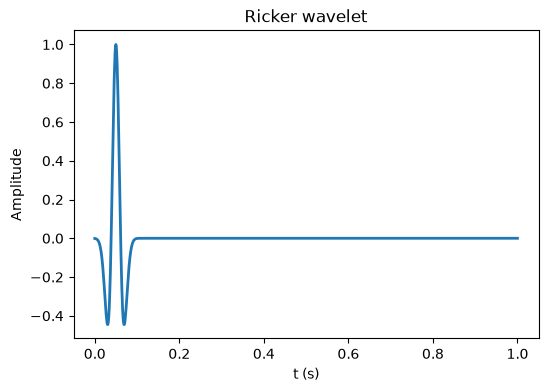

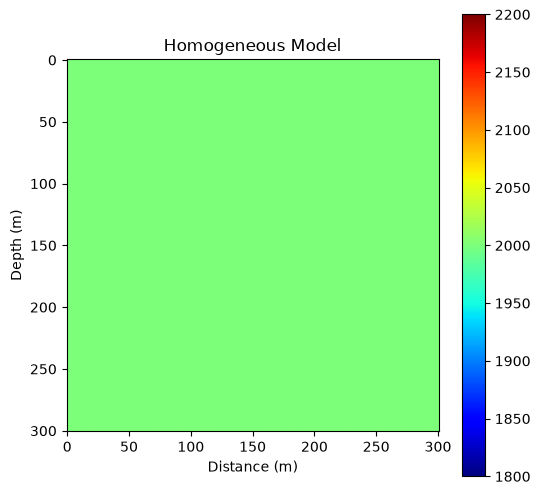

In [2]:
# Parameters
nx = 301
nz = 301
dx = 10.0
dz = 10.0
dt = 0.001
tmax = 1.0
nt = int(tmax / dt) + 1
t = np.arange(0, tmax + dt, dt)

# Finite-difference order
order = 8
coeff = fd_coefficients(order)
coeff = np.asarray(coeff,dtype=np.float64)
print("FD order =", order)
print("FD coefficients =", coeff)

# Source
f0 = 20.0
t0 = 1/f0
wavelet = ricker(t,f0,t0)
wavelet = np.asarray(wavelet, dtype=np.float64)
# Plot wavelet
plt.figure(figsize=(6, 4))
plt.plot(t,wavelet,linewidth=2)
plt.xlabel("t (s)")
plt.ylabel("Amplitude")
plt.title("Ricker wavelet")
plt.show()

# Source position
ix_src = nx // 2
iz_src = nz // 2

# Snapshot times
snapshot_times = np.array([1.0])
snapshot_steps = np.rint(snapshot_times / dt).astype(np.int64)

# Homogeneous velocity model
velocity_homo = homogeneous_model(nx,nz,2000.0)
velocity_homo = np.asarray(velocity_homo,dtype=np.float64)
# Plot velocity model
plt.figure(figsize=(6, 6))
plt.imshow(
        velocity_homo,
        cmap="jet",
    )
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.title("Homogeneous Model")
plt.colorbar()
plt.show()

In [3]:
# Run homogeneous model
snapshots_Dirichlet = acoustic_solver_Dirichlet(
    velocity_homo,
    wavelet,
    coeff,
    ix_src,
    iz_src,
    dx,
    dz,
    dt,
    snapshot_steps
)

Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s
Time step: 500 / 1001   Time: 0.5 s
Time step: 600 / 1001   Time: 0.6 s
Time step: 700 / 1001   Time: 0.7000000000000001 s
Time step: 800 / 1001   Time: 0.8 s
Time step: 900 / 1001   Time: 0.9 s
Time step: 1000 / 1001   Time: 1.0 s
Time step: 1001 / 1001   Time: 1.0010000000000001 s


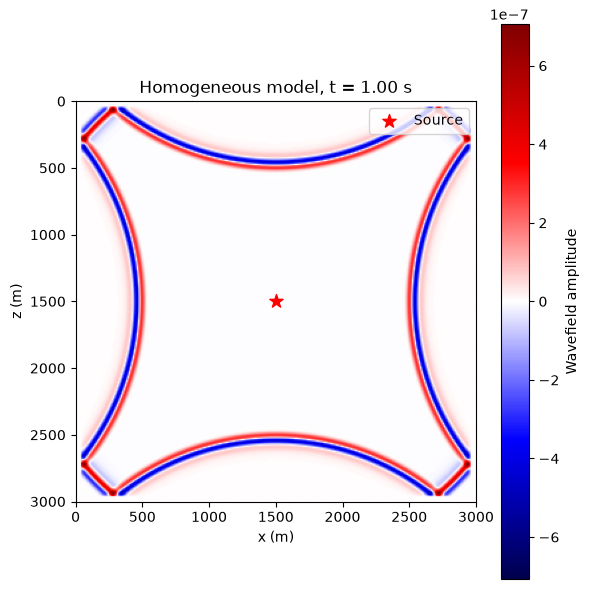

In [ ]:
# Plot homogeneous model snapshots
vmax = np.max(snapshots_Dirichlet)
for i in range(len(snapshot_times)):
    wavefield = snapshots_Dirichlet[i]
    plt.figure(figsize=(6, 6))
    im = plt.imshow(wavefield,
                    extent=[
                        0,
                        (nx - 1) * dx,
                        (nz - 1) * dz,
                        0
                        ],
                        cmap="seismic",
                        vmin=-vmax,
                        vmax=vmax
                    )
    plt.scatter(
        ix_src * dx,
        iz_src * dz,
        marker="*",
        s=100,
        label="Source",
        color='red'
    )
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title(f"Dirichlet boundary, t = {snapshot_times[i]:.2f} s")
    plt.colorbar(im,label="Wavefield amplitude",cmap="seismic")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [5]:
n_abs = 40
velocity_ext,sigma = damping_boundary(
    velocity_homo,
    dx,
    dz,
    n_abs,
    reflection=1e-6,
    power=2)
print(velocity_homo.shape)
print(velocity_ext.shape)
print(sigma.shape)

snapshots_Damping = acoustic_solver_Damping(
    velocity_ext,
    wavelet,
    coeff,
    ix_src,
    iz_src,
    dx,
    dz,
    dt,
    snapshot_steps,
    sigma,
    n_abs
)

(301, 301)
(381, 381)
(381, 381)
Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s
Time step: 500 / 1001   Time: 0.5 s
Time step: 600 / 1001   Time: 0.6 s
Time step: 700 / 1001   Time: 0.7000000000000001 s
Time step: 800 / 1001   Time: 0.8 s
Time step: 900 / 1001   Time: 0.9 s
Time step: 1000 / 1001   Time: 1.0 s
Time step: 1001 / 1001   Time: 1.0010000000000001 s


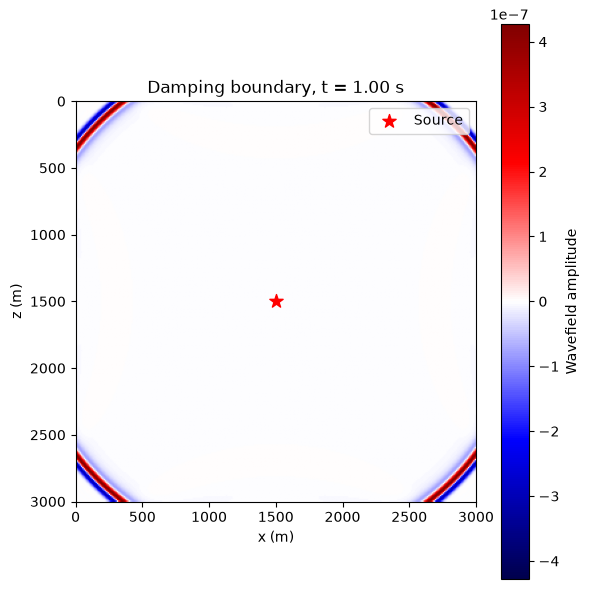

In [7]:
# Plot homogeneous model snapshots
vmax = np.max(snapshots_Damping)
for i in range(len(snapshot_times)):
    wavefield = snapshots_Damping[i]
    plt.figure(figsize=(6, 6))
    im = plt.imshow(wavefield,
                    extent=[
                        0,
                        (nx - 1) * dx,
                        (nz - 1) * dz,
                        0
                        ],
                        cmap="seismic",
                        vmin=-vmax,
                        vmax=vmax
                    )
    plt.scatter(
        ix_src * dx,
        iz_src * dz,
        marker="*",
        s=100,
        label="Source",
        color='red'
    )
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title(f"Damping boundary, t = {snapshot_times[i]:.2f} s")
    plt.colorbar(im,label="Wavefield amplitude",cmap="seismic")
    plt.legend()
    plt.tight_layout()
    plt.show()